In [ ]:
! rm -rf /content/*

rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/Shareddrives': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty


##Downloading all the required libraries



In [1]:
!pip install -q transformers gdown

In [2]:
import os
import glob
import json
import random
import shutil

import gdown
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Data Downloading and Preprocessing

### Manifesto Project - Dataset used for fine-tuning

For BERT fine-tuning, we use selected quasi-sentences from the Manifesto Project dataset. The original CMP codes are recoded into a binary task-specific label: `positive` or `negative`. This label represents the direction of the policy stance within the topics relevant for this project: migration, multiculturalism, human rights, military policy, peace, and international cooperation.

The selected CMP categories include:

- `601.2` — Immigration: Negative → `negative`
- `602.2` — Immigration: Positive → `positive`
- `607.2` — Immigrant Integration: Diversity → `positive`
- `608.2` — Immigrant Integration: Assimilation → `negative`
- `607.1` — Multiculturalism: Positive - General → `positive`
- `608.1` — Multiculturalism: Negative - General → `negative`
- `201.2` — Human Rights → `positive`
- `104` — Military: Positive → `positive`
- `105` — Military: Negative → `negative`
- `102` — Foreign Special Relationships: Negative → `negative`
- `106` — Peace → `negative` in this binary framing, because it captures anti-military statements
- `107` — Internationalism: Positive → `positive`
- `109` — Internationalism: Negative → `negative`

In [ ]:
df_manifesto_sft = pd.read_excel("Manifesto_filtered_v1.2.xlsx")
df_manifesto_sft.head()

,text,text_en,cmp_code,eu_code,pos,party_id,election_date,language,source,has_eu_code,...,per703_1,per703_2,rile,planeco,markeco,welfare,intpeace,datasetversion,id_perm,flag_contradiction
0,e che promuova una pace vera nel mondo.,and promotes true peace in the world.,106.0,NaN,40,32021,201302,italian,MARPOR,False,...,NaN,NaN,-20.531,2.657,2.657,16.425,2.899,2025a,U6ZCLP,False
1,"Vogliamo tagliare le spese militari, bloccare ...","We want to cut military spending, stop all pro...",105.0,NaN,411,32021,201302,italian,MARPOR,False,...,NaN,NaN,-20.531,2.657,2.657,16.425,2.899,2025a,U6ZCLP,False
2,Vogliamo far rispettare ed attuare l’articolo ...,We want to enforce and implement Article 11 of...,105.0,NaN,412,32021,201302,italian,MARPOR,False,...,NaN,NaN,-20.531,2.657,2.657,16.425,2.899,2025a,U6ZCLP,False
3,Vogliamo passare dalla sicurezza militare alla...,We want to move from military security to huma...,105.0,NaN,413,32021,201302,italian,MARPOR,False,...,NaN,NaN,-20.531,2.657,2.657,16.425,2.899,2025a,U6ZCLP,False
4,Contro la legge Di Paola che ipoteca più di 23...,Against Di Paola's law that mortgages more tha...,105.0,NaN,414,32021,201302,italian,MARPOR,False,...,NaN,NaN,-20.531,2.657,2.657,16.425,2.899,2025a,U6ZCLP,False


In [ ]:
df_manifesto_sft["cmp_code"] = df_manifesto_sft["cmp_code"].map({
    601.2: "negative",
    602.2: "positive",

    607.2: "positive",
    608.2: "negative",
    607.1: "positive",
    608.1: "negative",
    201.2: "positive",

    104: "positive",
    105: "negative",

    102: "negative",
    106: "negative",
    107: "positive",
    109: "negative"
})

We limit the set of analized countries to Italian (`32` - Italy) and English speaking ones (`51` - Great Britain, `61` -  United States, `63` -  Australia):

In [ ]:
# Here, we inspect the class distribution by country before balancin, as this helps identify whether one country or one class dominates the fine-tuning data.
df_manifesto_sft.groupby("country")["cmp_code"].value_counts()

country  cmp_code
32       positive     370
         negative     307
51       positive    3109
         negative     815
61       positive    2447
         negative     819
63       positive    4636
         negative     340
Name: count, dtype: int64

After downloading, the dataset is balanced manually. We do so to stop the model from overfitting to the specific language usage (e.g. giving greater probability of a positive class to English speeches) and forcing it to learn political sentiment phrasing.

Specifically, all negative examples and all Italian positive examples are kept because they are relatively scarce, and English positive examples are sampled to reach the target dataset size while preserving the country distribution observed among English negative examples.

In [ ]:
SEED = 42
TARGET_TOTAL = 5000

In [ ]:
df = df_manifesto_sft.copy()

# Negative cases are less numerous and are important for preserving the full range of oppositional policy statements.
df_neg = df[df["cmp_code"] == "negative"].copy()

# Italian positive cases are relatively scarce, and they are important because the downstream parliamentary data includes Italian text.
df_it_pos = df[
    (df["language"] == "italian") &
    (df["cmp_code"] == "positive")
].copy()

# English positive examples are more numerous, so they will be sampled.
df_en_pos = df[
    (df["language"] == "english") &
    (df["cmp_code"] == "positive")
].copy()

n_needed_en_pos = TARGET_TOTAL - len(df_neg) - len(df_it_pos)

print("All negative:", len(df_neg))
print("Italian positive:", len(df_it_pos))
print("English positive needed:", n_needed_en_pos)
print("English positive available:", len(df_en_pos))

All negative: 2281
Italian positive: 370
English positive needed: 2349
English positive available: 10192


After understanding the number of English positive examples needed to reach the target dataset size, we compute the country distribution among English negative examples. The goal of this task is to avoid creating a balanced dataset where positive examples come disproportionately from only one or two English-speaking countries:


In [ ]:
en_neg_counts_by_country = (
    df_neg[df_neg["language"] == "english"]
    .groupby("country")
    .size()
)

print(en_neg_counts_by_country)
country_weights = en_neg_counts_by_country / en_neg_counts_by_country.sum()


raw_targets = country_weights * n_needed_en_pos
target_pos_by_country = np.floor(raw_targets).astype(int)
# Because flooring loses some observations, we distribute the remaining quota to countries with the largest fractional parts
remainder = n_needed_en_pos - target_pos_by_country.sum()
fractional_parts = (raw_targets - np.floor(raw_targets)).sort_values(ascending=False)
for country in fractional_parts.index[:remainder]:
    target_pos_by_country.loc[country] += 1

print("Target English positive by country:")
print(target_pos_by_country)
print("Total:", target_pos_by_country.sum())

country
51    815
61    819
63    340
dtype: int64
Target English positive by country:
country
51    970
61    974
63    405
dtype: int64
Total: 2349


And now the distribution computed above is used as a template for sampling English positive examples:

In [ ]:
sampled_en_pos_parts = []

for country, n in target_pos_by_country.items():
    country_pos = df_en_pos[df_en_pos["country"] == country]

    sampled = country_pos.sample(
        n=n,
        random_state=SEED
    )

    sampled_en_pos_parts.append(sampled)

df_en_pos_sampled = pd.concat(sampled_en_pos_parts, axis=0)

Finally, we combine the final fine-tuning dataset with:
1. all negative examples,
2. all Italian positive examples,
3. sampled English positive examples

The dataset is then shuffled to avoid ordered blocks by language, country, or label.

In [ ]:
df_manifesto_balanced = pd.concat(
    [
        df_neg,
        df_it_pos,
        df_en_pos_sampled
    ],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Final size:", len(df_manifesto_balanced))
print()
print("By language and label:")
print(df_manifesto_balanced.groupby("language")["cmp_code"].value_counts())
print()
print("Proportions by language:")
print(pd.crosstab(
    df_manifesto_balanced["language"],
    df_manifesto_balanced["cmp_code"],
    normalize="index"
))

Final size: 5000

By language and label:
language  cmp_code
english   positive    2349
          negative    1974
italian   positive     370
          negative     307
Name: count, dtype: int64

Proportions by language:
cmp_code  negative  positive
language                    
english   0.456627  0.543373
italian   0.453471  0.546529


### UN + Parlamentary Speeches

The full description of the datasets used for the final analysis can be found in the report. Here, I simply download them for further usage:

Migration Parlament:

In [ ]:
df_migration_parl = pd.read_pickle("top_speeches_m.pkl")
df_migration_parl.head()

,row_id,speaker,party_family,text,year,text_clean,speech_id,sentence,sentence_id,keyword_hits,n_keyword_hits
0,2.006092e+07,CARLO GIOVANARDI,Christian democracy,"CARLO GIOVANARDI, . Signor Presidente, onorevo...",2006.0,"carlo giovanardi, . signor presidente, onorevo...",7062,"infatti, il permesso di soggiorno collegato al...",3,"['permesso di soggiorno', 'clandestini', 'trat...",4
1,2.006052e+07,LUCA VOLONTÈ,Christian democracy,"LUCA VOLONTE, . Signor Presidente, onorevoli c...",2006.0,"luca volonte, . signor presidente, onorevoli c...",437,amato non ha fatto cenno alla linea del govern...,10,"['sanatoria', 'sbarchi', 'immigrazione']",3
2,2.006052e+07,ALESSANDRO FORLANI,Christian democracy,"ALESSANDRO FORLANI, . Signor Presidente, onore...",2006.0,"alessandro forlani, . signor presidente, onore...",300,rispetto poi ad un'altra importante riforma de...,19,"['immigrati', 'immigrazione']",2
3,2.006092e+07,CARLO GIOVANARDI,Christian democracy,"CARLO GIOVANARDI, . Signor Presidente, ringraz...",2006.0,"carlo giovanardi, . signor presidente, ringraz...",7290,si tratta di adottare la misura giusta rispett...,4,"['irregolare', 'immigrazione']",2
4,2.006092e+07,CARLO GIOVANARDI,Christian democracy,"CARLO GIOVANARDI, . Signor Presidente, con ver...",2006.0,"carlo giovanardi, . signor presidente, con ver...",7623,mi spiegheranno i colleghi della sinistra come...,17,"['emigrati', 'immigrazione']",2


Military Parlament:

In [ ]:
df_military_parl = pd.read_pickle("top_speeches_w.pkl")
df_military_parl.head()

,row_id,speaker,party_family,text,year,text_clean,speech_id,sentence,sentence_id,keyword_hits,n_keyword_hits
0,2.006093e+07,MASSIMO NARDI,Christian democracy,"MASSIMO NARDI, . Signor Presidente, quando man...",2006.0,"massimo nardi, . signor presidente, quando man...",7954,"si tratta, infatti, non soltanto di militari c...",16,"[afghanistan, militari, libano, soldati, iraq]",5
1,2.006061e+07,MAURO DEL BUE,Christian democracy,"MAURO DEL BUE, . Prendo atto: se e cosi, e un ...",2006.0,"mauro del bue, . prendo atto: se e cosi, e un ...",904,ho apprezzato le parole di stamane del ministr...,3,"[afghanistan, iraq, missione di pace, continge...",4
2,2.006072e+07,MAURO DEL BUE,Christian democracy,"MAURO DEL BUE, . Signor Presidente, signor vic...",2006.0,"mauro del bue, . signor presidente, signor vic...",3342,mi piacerebbe anche sapere perche ritengono un...,71,"[afghanistan, missione di pace, militare, libano]",4
3,2.006093e+07,ALESSANDRO FORLANI,Christian democracy,"ALESSANDRO FORLANI, . Signor Presidente, onore...",2006.0,"alessandro forlani, . signor presidente, onore...",7793,"in questo spirito, con questo tipo di cultura ...",19,"[bosnia, libano, kosovo, somalia]",4
4,2.006072e+07,PIER FERDINANDO CASINI,Christian democracy,"PIER FERDINANDO CASINI, . Signor Presidente, v...",2006.0,"pier ferdinando casini, . signor presidente, v...",3863,votiamo a favore del presente provvedimento pe...,15,"[iraq, afghanistan, militari, difesa]",4


Migration UN:

In [ ]:
df_migration_un = pd.read_pickle("df_f1_m_un.pkl")
df_migration_un.head()

,row_id,DATE,TEXT,text_clean,sentence,sentence_id,keyword_hits,n_keyword_hits
0,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","it is that gap, above all, that causes the mas...",69,[migratory flows],1
1,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",in the mediterranean we are working with our p...,70,"[immigration, integration]",2
2,5,2011,Italy has a long tradition of \nmediation that...,italy has a long tradition of mediation that h...,"11-51378 10 on the face of it, the approach fa...",9,[migration],1
3,6,2012,"﻿I wish to warmly congratulate\nyou, Mr. Presi...","﻿i wish to warmly congratulate you, mr. presid...",we cannot overlook the importance of the measu...,13,[integration],1
4,6,2012,"﻿I wish to warmly congratulate\nyou, Mr. Presi...","﻿i wish to warmly congratulate you, mr. presid...",it will have to include such important dimensi...,77,[migration],1


Military UN:

In [ ]:
df_military_un = pd.read_pickle("df_f1_w_un.pkl")
df_military_un.head()

,row_id,DATE,TEXT,text_clean,sentence,sentence_id,keyword_hits,n_keyword_hits
0,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",they have rendered obsolete systems of collect...,9,"[defence, deterrence]",2
1,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",the recent experience in lebanon and the stren...,20,"[lebanon, unifil]",2
2,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","in lebanon we are still at square one, and muc...",22,[lebanon],1
3,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...","for, while it is true that europe provides the...",26,[unifil],1
4,0,2006,"I wish to offer you my \ncongratulations, Mada...","i wish to offer you my congratulations, madam ...",the question we must ask at this point is this...,27,[lebanon],1


## BERT Sensitivity analysis (with fine tuning)

### Fine-tuning

In [ ]:
# Converting string labels into numeric labels for BERT fine-tuning
df_manifesto_balanced["cmp_code"] = df_manifesto_balanced["cmp_code"].apply(lambda x: 1 if x == "positive" else 0)

Here, we create a stratification variable that combines language and label. We do so to preserve not only the overall positive/negative ratio, but also the label distribution within each language during the train/dev split:

In [ ]:
df_manifesto_balanced["strata"] = (
    df_manifesto_balanced["language"].astype(str) +
    "_" +
    df_manifesto_balanced["cmp_code"].astype(str)
)

# Create train, and dev set - there's no test split, as we will use another data for final analysis
train_df, dev_df = train_test_split(df_manifesto_balanced, test_size=0.2, random_state=SEED, stratify=df_manifesto_balanced["strata"])

In [ ]:
print("\nTrain balance:")
print(pd.crosstab(train_df["language"], train_df["cmp_code"], normalize="index"))

print("\nDev balance:")
print(pd.crosstab(dev_df["language"], dev_df["cmp_code"], normalize="index"))


Train balance:
cmp_code         0         1
language                    
english   0.456622  0.543378
italian   0.453875  0.546125

Dev balance:
cmp_code         0         1
language                    
english   0.456647  0.543353
italian   0.451852  0.548148


In [ ]:
X_train_sft = train_df["text"]
y_train_sft = train_df["cmp_code"]

X_dev_sft = dev_df["text"]
y_dev_sft = dev_df["cmp_code"]

As a base for fine-tuning, w use multilingual BERT because the fine-tuning data contains both English and Italian texts. The model was pre-trained on Wikipedia in multiple languages. Thus, we have a good basis, on which we can further develop and give model more functionalities to understand political domain

In [ ]:
# multilingual bert model trained on wikipedia
model_name = "google-bert/bert-base-multilingual-cased"

And then we follow the fine-tuning procedure set during seminars:

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(
    X_train_sft.tolist(), truncation=True, padding=True
)
val_encodings = tokenizer(X_dev_sft.tolist(), truncation=True, padding=True)

In [ ]:
label2id = {'negative': 0, 'positive': 1}
id2label = {0: 'negative', 1: 'positive'}

class ReviewDataset(torch.utils.data.Dataset):
    """PyTorch Dataset that wraps tokenized inputs and labels for the Trainer."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, y_train_sft.values)
val_dataset = ReviewDataset(val_encodings, y_dev_sft.values)

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    learning_rate = 3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    seed=SEED,
    optim='adamw_torch',
    eval_strategy="epoch",
    save_strategy="epoch",# We untroduce this parameter to evaluate each epoch. Without this, the dev set is not used during training to compare checkpoints
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1", ## At the end of training, reload the checkpoint with the best dev macro-f1
    greater_is_better=True,
    save_total_limit=2 # in order not to save many checkpoints and waste disk space
)

device = torch.device(type='cuda') if torch.cuda.is_available() else torch.device(type='cpu')

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(predictions_in):
    labels = predictions_in.label_ids
    predictions = predictions_in.predictions.argmax(-1)
    macrof1 = f1_score(y_true=labels, y_pred=predictions, average='macro')
    return {'macro_f1': macrof1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)] #if dev performance stops improving, training stops early instead of wasting compute.
    )

trainer.train()


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.513934,0.498307,0.766425
2,0.523719,0.535209,0.782434
3,0.317153,0.671299,0.807610
4,0.119968,0.839823,0.798518


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1000, training_loss=0.3688958883583546, metrics={'train_runtime': 876.7244, 'train_samples_per_second': 22.812, 'train_steps_per_second': 1.426, 'total_flos': 1307333056320000.0, 'train_loss': 0.3688958883583546, 'epoch': 4.0})

Eventually, the model stopped improving after the 3rd epoch and resulted in approximately 0.81 in terms of macro-f1, which we consider a good performance for our data. We also tried getting a tuned treshold for our predictions, but it resulted being 0.5, so we safely use the argmax function for obtaining predictions:

In [ ]:
pred_dev = trainer.predict(val_dataset)

In [ ]:
dev_probs = torch.softmax(torch.tensor(pred_dev.predictions), dim=1)[:, 1].numpy()

thresholds = np.arange(0.1, 0.91, 0.05)
best_threshold = max(
    thresholds,
    key=lambda t: f1_score(y_dev_sft.values, (dev_probs >= t).astype(int), average="macro")
)

print("Best dev threshold:", best_threshold)

Best dev threshold: 0.5000000000000001


Based on the confusion matrix and classification report, the model shows relatively balanced performance across both classes. The F1-scores for the negative and positive classes are close, 0.79 and 0.82 respectively, while the macro-F1 score is 0.81. This suggests that the model does not strongly favor one class over the other and is able to identify both negative and positive policy-stance statements with comparable accuracy

In [ ]:
logits = pred_dev.predictions
y_true = pred_dev.label_ids
y_pred = np.argmax(logits, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

[[362  94]
 [ 97 447]]
              precision    recall  f1-score   support

    negative       0.79      0.79      0.79       456
    positive       0.83      0.82      0.82       544

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



We're then saving the model and the treshold for further usage:

In [ ]:
save_dir = "./final_bert_model3_balanced_data"
os.makedirs(save_dir, exist_ok=True)

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

with open(f"{save_dir}/best_threshold.json", "w", encoding="utf-8") as f:
    json.dump({"best_threshold": float(best_threshold)}, f, ensure_ascii=False, indent=2)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
save_dir = "./final_bert_model3_balanced_data"

tokenizer = AutoTokenizer.from_pretrained(save_dir)
model = AutoModelForSequenceClassification.from_pretrained(save_dir)

with open(f"{save_dir}/best_threshold.json", "r", encoding="utf-8") as f:
    best_threshold = json.load(f)["best_threshold"]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
from google.colab import drive
import shutil
import os

drive.mount("/content/drive")

target_dir = "/content/drive/MyDrive/nlp_final_project_model3/final_bert_model3_balanced_data"

if os.path.exists(target_dir):
    shutil.rmtree(target_dir)

shutil.copytree("/content/final_bert_model3_balanced_data", target_dir)

print("Saved to:", target_dir)

Mounted at /content/drive
Saved to: /content/drive/MyDrive/nlp_final_project_model3/final_bert_model3_balanced_data


### Downloading the model

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
model_dir = "/content/drive/MyDrive/nlp_final_project_model3/final_bert_model3_balanced_data"

tokenizer = AutoTokenizer.from_pretrained(model_dir, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_dir, local_files_only=True)

with open(f"{model_dir}/best_threshold.json", "r") as f:
    threshold_data = json.load(f)

best_threshold = threshold_data["best_threshold"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Model loaded from:", model_dir)
print("Device:", device)
print("Best threshold:", best_threshold)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded from: /content/drive/MyDrive/nlp_final_project_model3/final_bert_model3_balanced_data
Device: cuda
Best threshold: 0.5000000000000001


### Evaluating

In [ ]:
def get_positive_scores(texts, tokenizer, model, batch_size=16):
    """
    Compute the predicted probability of the positive class for a list of texts.
    The function returns only the probability of class 1 ("positive"), as this
    score is later compared with a classification threshold to assign the final label.
    """
    all_scores = []

    # We process the texts in batches to make inference more memory-efficient.
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)
            positive_probs = probs[:, 1].detach().cpu().numpy()

        all_scores.extend(positive_probs)

    return all_scores

In [ ]:
def label_dataset(
    df,
    text_col,
    tokenizer,
    model,
    threshold,
    batch_size=16
):
    """ Apply the fine-tuned BERT classifier to a dataset and add predicted labels.
    This function takes a dataframe with a text column, computes the BERT positive
    class probability for each text, and converts this probability into a binary
    label using the selected threshold.
    """
    df_out = df.copy()

    texts = df_out[text_col].fillna("").astype(str).tolist()

    positive_scores = get_positive_scores(
        texts=texts,
        tokenizer=tokenizer,
        model=model,
        batch_size=batch_size
    )

    # Convert probabilities into binary predictions using the selected threshold
    pred_labels_num = [1 if score >= threshold else 0 for score in positive_scores]
    pred_labels_text = ["positive" if label == 1 else "negative" for label in pred_labels_num]

    df_out["bert_positive_score"] = positive_scores
    df_out["bert_pred_label_num"] = pred_labels_num
    df_out["bert_pred_label"] = pred_labels_text

    return df_out

We then apply the functions presented above for each of the topic-field combination and aggregate the sentiment counts. In the end of this section, this shares will be used to analyse differences across the obtained results.

Migration Parlament

In [ ]:
df_migration_parl_labeled = label_dataset(
    df=df_migration_parl,
    text_col="sentence",
    tokenizer=tokenizer,
    model=model,
    threshold=best_threshold,
    batch_size=16
)

  0%|          | 0/611 [00:00<?, ?it/s]

In [ ]:
df_migration_parl_labeled["bert_pred_label"].value_counts(normalize=True)

,proportion
bert_pred_label,
negative,0.538194
positive,0.461806


In [ ]:
df_migration_parl_labeled_25 = df_migration_parl_labeled.sample(n=25, random_state=11)[[
    "sentence",
    "bert_positive_score",
    "bert_pred_label_num",
    "bert_pred_label"
]]
df_migration_parl_labeled_25["dataset_source"] = "migration_parl"

Military Parlament

In [ ]:
df_military_parl_labeled = label_dataset(
    df=df_military_parl,
    text_col="sentence",
    tokenizer=tokenizer,
    model=model,
    threshold=best_threshold,
    batch_size=16
)

  0%|          | 0/628 [00:00<?, ?it/s]

In [ ]:
df_military_parl_labeled["bert_pred_label"].value_counts(normalize=True)

,proportion
bert_pred_label,
negative,0.692016
positive,0.307984


In [ ]:
df_military_parl_labeled_25 = df_military_parl_labeled.sample(n=25, random_state=21)[[
    "sentence",
    "bert_positive_score",
    "bert_pred_label_num",
    "bert_pred_label"
]]
df_military_parl_labeled_25["dataset_source"] = "military_parl"

Migration UN

In [ ]:
df_migration_un_labeled = label_dataset(
    df=df_migration_un,
    text_col="sentence",
    tokenizer=tokenizer,
    model=model,
    threshold=best_threshold,
    batch_size=16
)

  0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
df_migration_un_labeled["bert_pred_label"].value_counts(normalize=True)

,proportion
bert_pred_label,
positive,0.71875
negative,0.28125


In [ ]:
df_migration_un_labeled_25 = df_migration_un_labeled.sample(n=25, random_state=31)[[
    "sentence",
    "bert_positive_score",
    "bert_pred_label_num",
    "bert_pred_label"
]]
df_migration_un_labeled_25["dataset_source"] = "migration_un"

Military UN

In [ ]:
df_military_un_labeled = label_dataset(
    df=df_military_un,
    text_col="sentence",
    tokenizer=tokenizer,
    model=model,
    threshold=best_threshold,
    batch_size=16
)

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
df_military_un_labeled["bert_pred_label"].value_counts(normalize=True)

,proportion
bert_pred_label,
positive,0.602564
negative,0.397436


In [ ]:
df_military_un_labeled_25 = df_military_un_labeled.sample(n=25, random_state=41)[[
    "sentence",
    "bert_positive_score",
    "bert_pred_label_num",
    "bert_pred_label"
]]
df_military_un_labeled["dataset_source"] = "military_un"

The model results reveal notable differences in predicted policy stance across domains. Parliamentary speeches are classified as predominantly negative: 54% of migration-related parliamentary sentences and 69% of military-related parliamentary sentences receive a negative label. In contrast, UN speeches are classified as predominantly positive, with 72% positive predictions for migration-related sentences and 60% for military-related sentences.

There are several possible explanations for this pattern.

First, the difference may reflect the institutional context in which the speeches are produced. UN speeches are delivered in a highly diplomatic international setting, where political actors may be more likely to use cooperative, normatively acceptable, and internationally oriented language. This can include support for migration governance, human rights, international cooperation, peacekeeping, or collective security. Parliamentary debates, by contrast, often involve domestic political competition and may give more space to criticism, contestation, and expressions of concern about the economic, social, or security consequences of migration and military engagement.

Second, the results may partly reflect language effects. The parliamentary data is in Italian, while the UN data is in English. Since the model was trained on multilingual data but applied across different linguistic and institutional contexts, it is possible that Italian political language contains rhetorical or expressive patterns that the model is more likely to associate with the negative class. Therefore, part of the observed difference may come from cross-linguistic variation.

Third, the results may be influenced by the specificity of the fine-tuning data. The BERT model was fine-tuned on Manifesto Project quasi-sentences, which differ from parliamentary and UN speeches in genre, style, and communicative purpose. Even though the fine-tuning dataset was balanced, the model may still have learned patterns that are specific to manifesto language rather than political speeches more generally. This domain mismatch should be taken into account when interpreting the results.

Overall, the findings suggest a clear difference between parliamentary and UN discourse, with domestic parliamentary speeches appearing more negative and international UN speeches appearing more positive. However, these results should be interpreted as model-based estimates of policy stance rather than direct measures of political sentiment. Further work could improve the robustness of the analysis by adding more training data from parliamentary and diplomatic speeches.

### Year subperiods analysis

As a further step of analysis, we decided to see how the sentiments were evolving through the analysed period of time. Specifically, we divide the analysis into three periods: 2006–2013, 2014–2017, and 2018–2022:

1. `2006–2013`: captures the pre- and post-global financial crisis years, including the immediate aftermath of the 2008 crisis and the early 2010s period of political and economic adjustment.

2. `2014–2017`: reflects a phase of intensified geopolitical instability and political realignment, including the Ukraine crisis, the escalation of conflicts in the Middle East, the European migration crisis, and Brexit.

3. `2018–2022`: captures the late 2010s and early 2020s, marked by continued geopolitical fragmentation, the COVID-19 pandemic, and the beginning of the Russia–Ukraine war.

This division therefore provides analytically meaningful periods while avoiding excessive fragmentation of the dataset

In [ ]:
period_bins = [2005, 2013, 2017, 2022]
period_labels = ["2006–2013", "2014–2017", "2018–2022"]
label_order = ["negative", "positive"]

In [ ]:
def add_period(df, year_col="year"):
    df_out = df.copy()

    df_out[year_col] = pd.to_numeric(df_out[year_col], errors="coerce")

    df_out["period"] = pd.cut(
        df_out[year_col],
        bins=period_bins,
        labels=period_labels
    )

    return df_out

In [ ]:
def get_period_label_shares(df, dataset_name, year_col):
    """
    Compute the share and count of BERT-predicted labels within each time period.

    The function first assigns each observation to a broader historical
    period using the add_period() function. It then calculates, for each period,
    the proportion and the absolute number of observations classified as
    "positive" or "negative" by the fine-tuned BERT model.
    """

    df_period = add_period(df, year_col=year_col)
    df_period = df_period.dropna(subset=["period"]).copy()

    # Compute the share of each predicted label within each period
    shares = (
        df_period
        .groupby("period", observed=False)["bert_pred_label"]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
    )

    # Reshape the label shares into a wide format: one row per period, one column per label
    shares_wide = (
        shares
        .pivot(
            index="period",
            columns="bert_pred_label",
            values="share"
        )
        .fillna(0)
        .reindex(period_labels)
    )

    # Compute the absolute number of observations for each label within each period
    counts = (
        df_period
        .groupby(["period", "bert_pred_label"], observed=False)
        .size()
        .rename("count")
        .reset_index()
    )

    # Reshape the counts into a wide format
    counts_wide = (
        counts
        .pivot(
            index="period",
            columns="bert_pred_label",
            values="count"
        )
        .fillna(0)
        .reindex(period_labels)
    )

    # Ensure that all expected label columns are present in both tables
    for label in label_order:
        if label not in shares_wide.columns:
            shares_wide[label] = 0
        if label not in counts_wide.columns:
            counts_wide[label] = 0

    # Keep the label columns in a consistent order across all datasets
    shares_wide = shares_wide[label_order]
    counts_wide = counts_wide[label_order]

    # Rename count columns to distinguish them from share columns
    counts_wide = counts_wide.rename(
        columns={label: f"n_{label}" for label in label_order}
    )

    # Combine relative shares and absolute counts into one summary table
    result = pd.concat(
        [shares_wide, counts_wide],
        axis=1
    )

    # Add the total number of observations in each period
    result["n_total"] = result[[f"n_{label}" for label in label_order]].sum(axis=1)

    # Store the dataset name for easier comparison after combining outputs from different sources, such as parliamentary and UN speeches
    result["dataset"] = dataset_name

    count_cols = [f"n_{label}" for label in label_order] + ["n_total"]
    result[count_cols] = result[count_cols].astype(int)

    return result.reset_index()

In [ ]:
datasets = {
    "Migration — Parliament": {
        "df": df_migration_parl_labeled,
        "year_col": "year"
    },
    "Military — Parliament": {
        "df": df_military_parl_labeled,
        "year_col": "year"
    },
    "Migration — UN": {
        "df": df_migration_un_labeled,
        "year_col": "DATE"
    },
    "Military — UN": {
        "df": df_military_un_labeled,
        "year_col": "DATE"
    }
}

In [ ]:
period_results = []

for name, info in datasets.items():
    result = get_period_label_shares(
        df=info["df"],
        dataset_name=name,
        year_col=info["year_col"]
    )
    period_results.append(result)

period_label_shares_all = pd.concat(period_results, ignore_index=True)

period_label_shares_all

bert_pred_label,period,negative,positive,n_negative,n_positive,n_total,dataset
0,2006–2013,0.565816,0.434184,2506,1923,4429,Migration — Parliament
1,2014–2017,0.524050,0.475950,1351,1227,2578,Migration — Parliament
2,2018–2022,0.507068,0.492932,1399,1360,2759,Migration — Parliament
3,2006–2013,0.733160,0.266840,3385,1232,4617,Military — Parliament
4,2014–2017,0.656881,0.343119,1723,900,2623,Military — Parliament
5,2018–2022,0.657000,0.343000,1835,958,2793,Military — Parliament
6,2006–2013,0.142857,0.857143,2,12,14,Migration — UN
7,2014–2017,0.346154,0.653846,9,17,26,Migration — UN
8,2018–2022,0.291667,0.708333,7,17,24,Migration — UN
9,2006–2013,0.418182,0.581818,23,32,55,Military — UN


For better interpretation, we'll present this table as a graph:

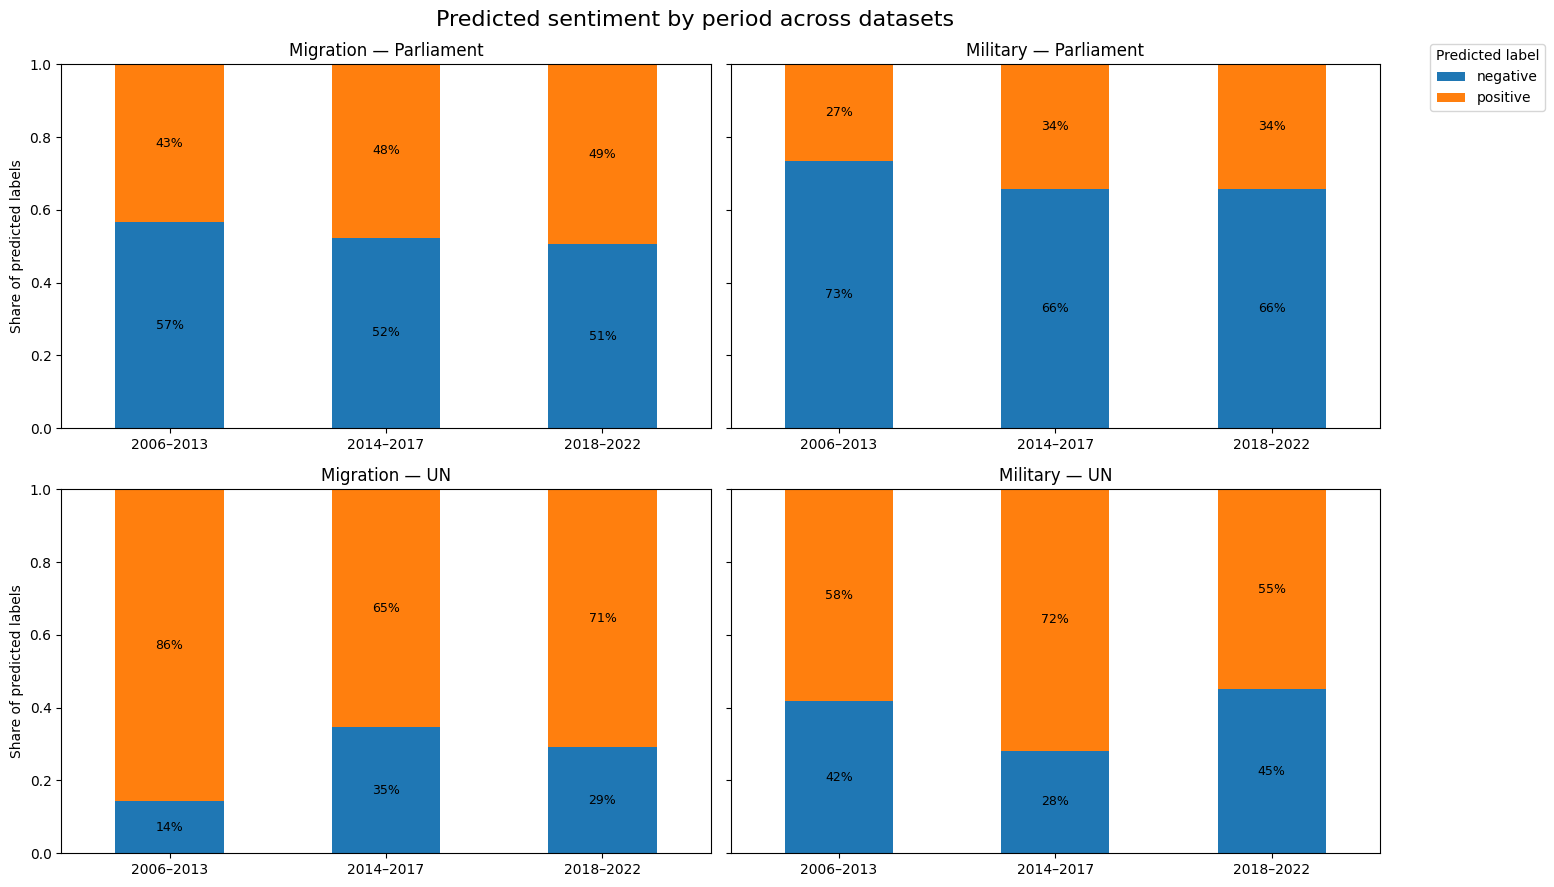

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for ax, (name, info) in zip(axes, datasets.items()):
    shares = get_period_label_shares(
        df=info["df"],
        dataset_name=name,
        year_col=info["year_col"]
    )

    plot_df = (
        shares
        .set_index("period")[label_order]
        .reindex(period_labels)
    )

    plot_df.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False
    )

    ax.set_title(name)
    ax.set_xlabel("")
    ax.set_ylabel("Share of predicted labels")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)

    for container in ax.containers:
        labels = [
            f"{v.get_height():.0%}" if v.get_height() > 0.05 else ""
            for v in container
        ]
        ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Predicted label",
    bbox_to_anchor=(1.02, 0.95),
    loc="upper left"
)

fig.suptitle("Predicted sentiment by period across datasets", fontsize=16)

plt.tight_layout()
plt.show()

**Migration — Parliament.**
The distribution is relatively balanced across all three periods, but there is a gradual movement toward more positive sentiment: positive labels increase from 43% in 2006–2013 to 48% in 2014–2017 and 49% in 2018–2022. This suggests that parliamentary discourse on migration remains contested, but may become slightly less negative over time, possibly reflecting a shift from crisis- or security-oriented framing toward more pragmatic discussions of integration, rights, or labor.

**Military — Parliament.**
Military-related parliamentary discourse is consistently dominated by negative sentiment, although negativity decreases from 73% in 2006–2013 to 66% in the later two periods. The persistence of negative sentiment suggests that military topics remain strongly associated with conflict and risk.

**Migration — UN.**
UN discourse on migration is predominantly positive in all periods, especially in 2006–2013, where positive sentiment reaches 86%. It drops to 65% in 2014–2017, which may reflect the impact of the European refugee crisis and broader debates around displacement and border management. The increase to 71% in 2018–2022 may indicate a partial return to more cooperative, and humanitarian framing. This shift can also be related to the COVID-19, when international mobility declined sharply due to lockdowns and travel restrictions, potentially reducing the salience of migration as an immediate border-control crisis and allowing it to be discussed more in terms of protection, resilience, and international cooperation.

**Military — UN.**
Military-related UN discourse is also more positive than parliamentary discourse, but it fluctuates more visibly. Positive sentiment rises from 58% in 2006–2013 to 72% in 2014–2017, then falls to 55% in 2018–2022. The increase in the middle period may be connected to renewed geopolitical tensions, including the Russia–Ukraine crisis (Crimea) and the broader deterioration of international security. The fall in the end can also be related to COVID, as a resource for distraction from global conflicts and a greater focus on cooperation and non-violent conflict resolution.

### Robustness check - self-labelling the data and comparing the results of the model:

Finally, to add extra validity to our model results, we've asked an independent annotator to classify for us a random subsample of data (25 observations for each of the categories' combination) to then compare it to the model results:

In [ ]:
df_migration_parl_labeled_25_out = df_migration_parl_labeled_25.copy()
df_migration_parl_labeled_25_out["dataset_source"] = "migration_parl"

df_military_parl_labeled_25_out = df_military_parl_labeled_25.copy()
df_military_parl_labeled_25_out["dataset_source"] = "military_parl"

df_migration_un_labeled_25_out = df_migration_un_labeled_25.copy()
df_migration_un_labeled_25_out["dataset_source"] = "migration_un"

df_military_un_labeled_25_out = df_military_un_labeled_25.copy()
df_military_un_labeled_25_out["dataset_source"] = "military_un"

df_all_labeled_samples = pd.concat(
    [
        df_migration_parl_labeled_25_out,
        df_military_parl_labeled_25_out,
        df_migration_un_labeled_25_out,
        df_military_un_labeled_25_out
    ],
    axis=0,
    ignore_index=True
)

print(len(df_all_labeled_samples))
print(df_all_labeled_samples["dataset_source"].value_counts())

100
dataset_source
migration_parl    25
military_parl     25
migration_un      25
military_un       25
Name: count, dtype: int64


In [ ]:
df_all_labeled_samples['bert_pred_label'].value_counts()

,count
bert_pred_label,
positive,53
negative,47


In [ ]:
df_all_labeled_samples.to_excel("/content/all_labeled_samples.xlsx", index=False)

Upload the dataset again with the annotator's classification (they didn't see the model labels, as it would have biased our results):

In [4]:
df_all_labeled_samples = pd.read_excel("/content/all_labeled_samples.xlsx")

In [6]:
df_all_labeled_samples['match_labels'] = df_all_labeled_samples['annotation'] == df_all_labeled_samples['bert_pred_label_num']

In [11]:
df_all_labeled_samples['match_labels'].value_counts(normalize = True)

,proportion
match_labels,
True,0.72
False,0.28


In [13]:
df_all_labeled_samples.groupby('bert_pred_label')['match_labels'].value_counts(normalize = True)

bert_pred_label  match_labels
negative         True            0.638298
                 False           0.361702
positive         True            0.792453
                 False           0.207547
Name: proportion, dtype: float64

In [10]:
df_all_labeled_samples.groupby('dataset_source')['match_labels'].value_counts(normalize = True)

dataset_source  match_labels
migration_parl  True            0.56
                False           0.44
migration_un    True            0.72
                False           0.28
military_parl   True            0.80
                False           0.20
military_un     True            0.80
                False           0.20
Name: proportion, dtype: float64

Overall, the results are reasonably encouraging: 72% of the model predictions match the human labels.

The agreement is higher for texts predicted as positive than for texts predicted as negative. Around 79% of positive predictions match the human annotation, compared to about 64% of negative predictions. This difference is not unexpected, since negative examples were slightly less represented in the supervised fine-tuning data. As a result, the model may have learned the negative class somewhat less robustly.

The comparison by dataset source also suggests that disagreement is more common in the parliamentary speech datasets, especially in the migration-related parliamentary texts. This may reflect cross-linguistic and domain-specific challenges. Although the model is based on multilingual BERT and was fine-tuned on both English and Italian Manifesto Project data, Italian examples were less numerous in the supervised fine-tuning dataset. In addition, parliamentary speeches differ from Manifesto quasi-sentences in style, rhetoric, and context, which may make classification more difficult.

At the same time, this validation should be interpreted with caution. The comparison is based on labels from a single annotator, so the human labels may also contain subjective judgments or individual bias.

To sum up, future research could improve the reliability of the validation by expanding the supervised fine-tuning dataset, adding more Italian and speech-based training examples, and involving multiple annotators to measure inter-annotator agreement.